# Dataset 4 – Credit Approval
**Implementation:** Akshit (algorithms/akshit/)  
**Algorithms:** TBD  
**Note:** Mixed features — use `utils.one_hot_encode` for categorical columns  
**Evaluation:** Stratified 10-fold CV · Accuracy · Macro F1

In [ ]:
import sys, os, subprocess

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run(['git', 'clone', f'https://github.com/vishalhanuman14/classical-ml-benchmark.git'], check=True)
    os.chdir('classical-ml-benchmark')

if '.' not in sys.path:
    sys.path.insert(0, '.')


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
sys.path.insert(0, '.')

from algorithms.vishal import utils

df = pd.read_csv('data/credit_approval.csv')
print(df.head(2))
print(f"Shape: {df.shape}")
print(f"Dtypes:\n{df.dtypes}")


  attr1_cat  attr2_num  attr3_num attr4_cat attr5_cat attr6_cat attr7_cat  \
0         b      30.83       0.00         u         g         w         v   
1         a      58.67       4.46         u         g         q         h   

   attr8_num attr9_cat attr10_cat  attr11_cat attr12_cat attr13_cat  \
0       1.25         t          t           1          f          g   
1       3.04         t          t           6          f          g   

   attr14_num  attr15_num  label  
0         202           0      1  
1          43         560      1  
Shape: (653, 16)
Dtypes:
attr1_cat      object
attr2_num     float64
attr3_num     float64
attr4_cat      object
attr5_cat      object
attr6_cat      object
attr7_cat      object
attr8_num     float64
attr9_cat      object
attr10_cat     object
attr11_cat      int64
attr12_cat     object
attr13_cat     object
attr14_num      int64
attr15_num      int64
label           int64
dtype: object


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import your custom functions from hw_3.py
from algorithms.akshit.hw_3 import DecisionTree, RandomForest, evaluate_metrics, stratified_kfold

# Import the shared utilities
from algorithms.vishal import utils

# --- Data Loading ---
df = pd.read_csv('data/credit_approval.csv')

# Dynamically identify target and features (assuming target is the last column)
target_col = df.columns[-1]
feature_cols = df.columns.drop(target_col)

# Identify categorical and numerical feature indices
cat_columns = [i for i, col in enumerate(feature_cols) if df[col].dtype == object]
num_columns = [i for i, col in enumerate(feature_cols) if df[col].dtype != object]

X_str = df[feature_cols].values.astype(str)
y = df[target_col].values.astype(str)

# Apply one-hot encoding to handle the mixed features
X_enc = utils.one_hot_encode(X_str, cat_indices=cat_columns, num_indices=num_columns)
X_raw = X_enc.astype(float) # Cast to float for mathematical operations

print(f"Instances: {len(y)}, Features (after encoding): {X_raw.shape[1]}")
print(f"Classes: {dict(zip(*np.unique(y, return_counts=True)))}")

Instances: 653, Features (after encoding): 46
Classes: {np.str_('0'): np.int64(357), np.str_('1'): np.int64(296)}


## TODO: Algorithm 1 – Hyperparameter Sweep

In [ ]:
# --- Algorithm 1 Sweep: Decision Tree ---
depth_values = [2, 4, 6, 8, 10, 15]
dt_results = {'max_depth': [], 'accuracy': [], 'f1': []}

print("Running 10-Fold CV for Decision Tree...")
folds = stratified_kfold(X_raw, y, k=10)

for depth in depth_values:
    acc_list, f1_list = [], []
    for train_idx, test_idx in folds:
        X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Initialize and train Decision Tree
        dt = DecisionTree(max_depth=depth, min_size_for_split=2)
        dt.fit(X_tr, y_tr)

        # Predict and evaluate
        y_pred = dt.predict(X_te)
        acc, prec, rec, f1 = evaluate_metrics(y_te, y_pred)

        acc_list.append(acc)
        f1_list.append(f1)

    dt_results['max_depth'].append(depth)
    dt_results['accuracy'].append(np.mean(acc_list))
    dt_results['f1'].append(np.mean(f1_list))
    print(f"max_depth={depth:<2} | Acc: {np.mean(acc_list):.4f} | F1: {np.mean(f1_list):.4f}")

Running 10-Fold CV for Decision Tree...
max_depth=2  | Acc: 0.8638 | F1: 0.8631
max_depth=4  | Acc: 0.8440 | F1: 0.8275
max_depth=6  | Acc: 0.8410 | F1: 0.8279
max_depth=8  | Acc: 0.8331 | F1: 0.8170
max_depth=10 | Acc: 0.8302 | F1: 0.8112
max_depth=15 | Acc: 0.8255 | F1: 0.8052


## TODO: Algorithm 2 – Hyperparameter Sweep

In [ ]:
# --- Algorithm 2 Sweep: Random Forest ---
ntree_values = [1, 5, 10, 20, 30]
rf_results = {'ntree': [], 'accuracy': [], 'f1': []}

print("Running 10-Fold CV for Random Forest...")

for ntree in ntree_values:
    acc_list, f1_list = [], []
    for train_idx, test_idx in folds: # Reusing the exact same folds for a fair comparison
        X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Initialize and train Random Forest
        rf = RandomForest(ntree=ntree, max_depth=8)
        rf.fit(X_tr, y_tr)

        # Predict and evaluate
        y_pred = rf.predict(X_te)
        acc, prec, rec, f1 = evaluate_metrics(y_te, y_pred)

        acc_list.append(acc)
        f1_list.append(f1)

    rf_results['ntree'].append(ntree)
    rf_results['accuracy'].append(np.mean(acc_list))
    rf_results['f1'].append(np.mean(f1_list))
    print(f"ntree={ntree:<2} | Acc: {np.mean(acc_list):.4f} | F1: {np.mean(f1_list):.4f}")

Running 10-Fold CV for Random Forest...
ntree=1  | Acc: 0.8087 | F1: 0.7829
ntree=5  | Acc: 0.8605 | F1: 0.8480
ntree=10 | Acc: 0.8562 | F1: 0.8445
ntree=20 | Acc: 0.8761 | F1: 0.8650
ntree=30 | Acc: 0.8669 | F1: 0.8568


## TODO: Plots & Summary Table

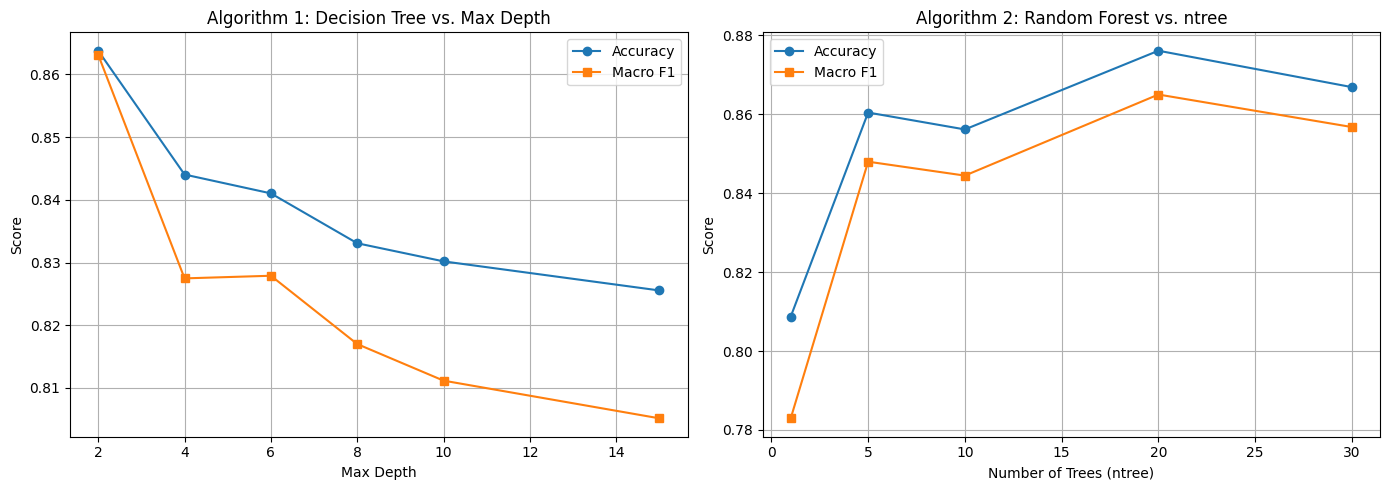


=== SUMMARY TABLE ===
Decision Tree Results:
 max_depth  accuracy       f1
         2  0.863781 0.863128
         4  0.844037 0.827476
         6  0.841030 0.827895
         8  0.833077 0.817001
        10  0.830188 0.811168
        15  0.825548 0.805156

Random Forest Results:
 ntree  accuracy       f1
     1  0.808716 0.782940
     5  0.860467 0.848007
    10  0.856182 0.844478
    20  0.876139 0.865033
    30  0.866906 0.856786


In [ ]:
# --- Plotting Learning Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree Plot
axes[0].plot(dt_results['max_depth'], dt_results['accuracy'], marker='o', label='Accuracy')
axes[0].plot(dt_results['max_depth'], dt_results['f1'], marker='s', label='Macro F1')
axes[0].set_title('Algorithm 1: Decision Tree vs. Max Depth')
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True)

# Random Forest Plot
axes[1].plot(rf_results['ntree'], rf_results['accuracy'], marker='o', label='Accuracy')
axes[1].plot(rf_results['ntree'], rf_results['f1'], marker='s', label='Macro F1')
axes[1].set_title('Algorithm 2: Random Forest vs. ntree')
axes[1].set_xlabel('Number of Trees (ntree)')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\n=== SUMMARY TABLE ===")
print("Decision Tree Results:")
df_dt = pd.DataFrame(dt_results)
print(df_dt.to_string(index=False))

print("\nRandom Forest Results:")
df_rf = pd.DataFrame(rf_results)
print(df_rf.to_string(index=False))